## **Data Science Internship – Task 4**

# **Mini Visualization Dashboard (Student Data)**

### **STEP 1:Import Libraries**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

### **STEP 2: Load Dataset**

In [6]:
import zipfile
import pandas as pd

# Load dataset from zip
with zipfile.ZipFile(r"C:\Users\sanik\Downloads\student.zip") as z:
    with z.open("student-mat.csv") as f:
        df = pd.read_csv(f, sep=';')   # IMPORTANT

# Preview data
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### **STEP 3:Clean Data**

**Aim:** To check missing values.

In [10]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

**Aim:** To Remove duplicates.

In [13]:
df.duplicated().sum()
df = df.drop_duplicates()

### **STEP 4:Feature Engineering**

**Aim:** To create useful features for analysis.

In [17]:
df['Result'] = df['G3'].apply(lambda x: 'Pass' if x >= 10 else 'Fail')

df['GradeCategory'] = pd.cut(df['G3'], bins=[0,10,15,20], labels=['Low','Medium','High'])

### **STEP 5:Dashboard Plots**

**i)Histogram – Final Grade Distribution**

**Aim:** To visualize distribution of final grades.

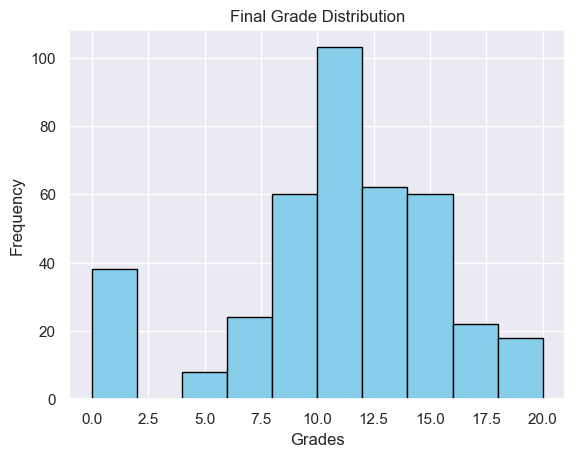

In [22]:
plt.figure()
plt.hist(df['G3'], bins=10, color='skyblue', edgecolor='black')
plt.title("Final Grade Distribution")
plt.xlabel("Grades")
plt.ylabel("Frequency")
plt.show()

**Result:** The graph shows that most students scored in the middle range.

**ii)Bar Chart – Average Grade by Gender**

**Aim:** To compare performance by gender.

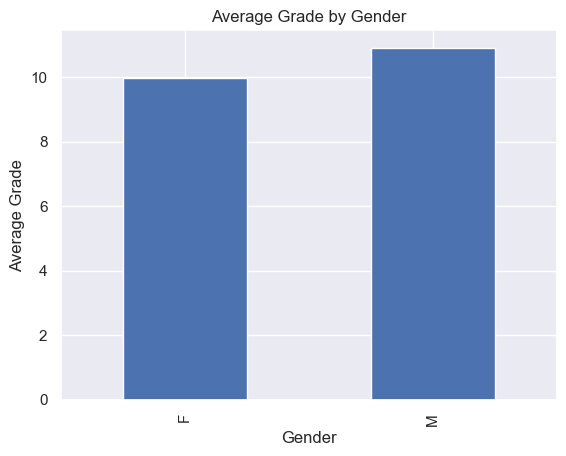

In [27]:
df.groupby('sex')['G3'].mean().plot(kind='bar')
plt.title("Average Grade by Gender")
plt.xlabel("Gender")
plt.ylabel("Average Grade")
plt.show()

**Result:** The graph shows that male students have slightly higher average grades than female students.

**iii)Boxplot – Study Time vs Grades**

**Aim:** To analyze grade distribution based on study time.

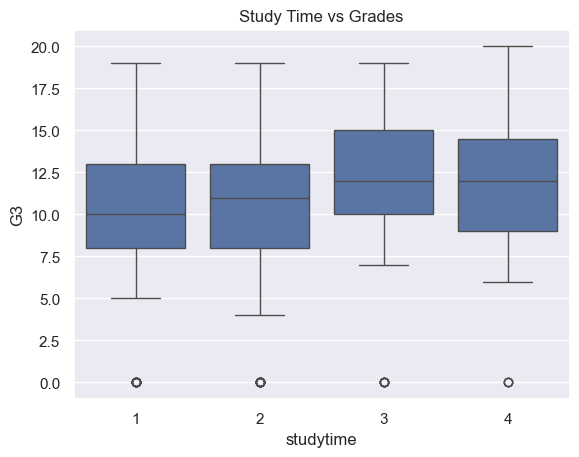

In [32]:
sns.boxplot(x='studytime', y='G3', data=df)
plt.title("Study Time vs Grades")
plt.show()

**Result:** The graph shows that higher study time is associated with better performance.

**iv)Scatter Plot – Study Time vs Grade**

**Aim:** To examine relationship between study time and grades.

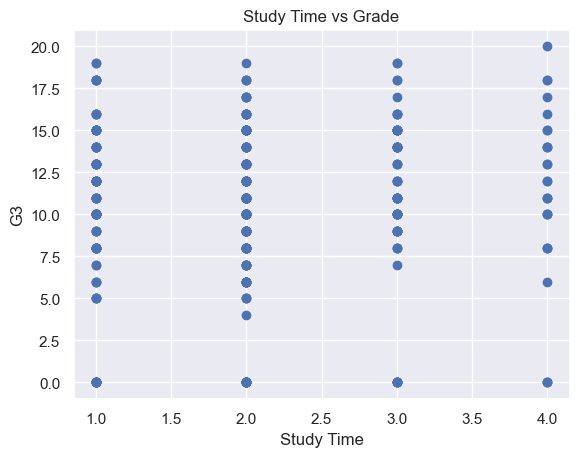

In [37]:
plt.figure()
plt.scatter(df['studytime'], df['G3'])
plt.title("Study Time vs Grade")
plt.xlabel("Study Time")
plt.ylabel("G3")
plt.show()

**Result:** The graph shows a slight positive relationship between study time and grades.

**v)Heatmap – Correlation**

**Aim:** To identify relationships between variables.

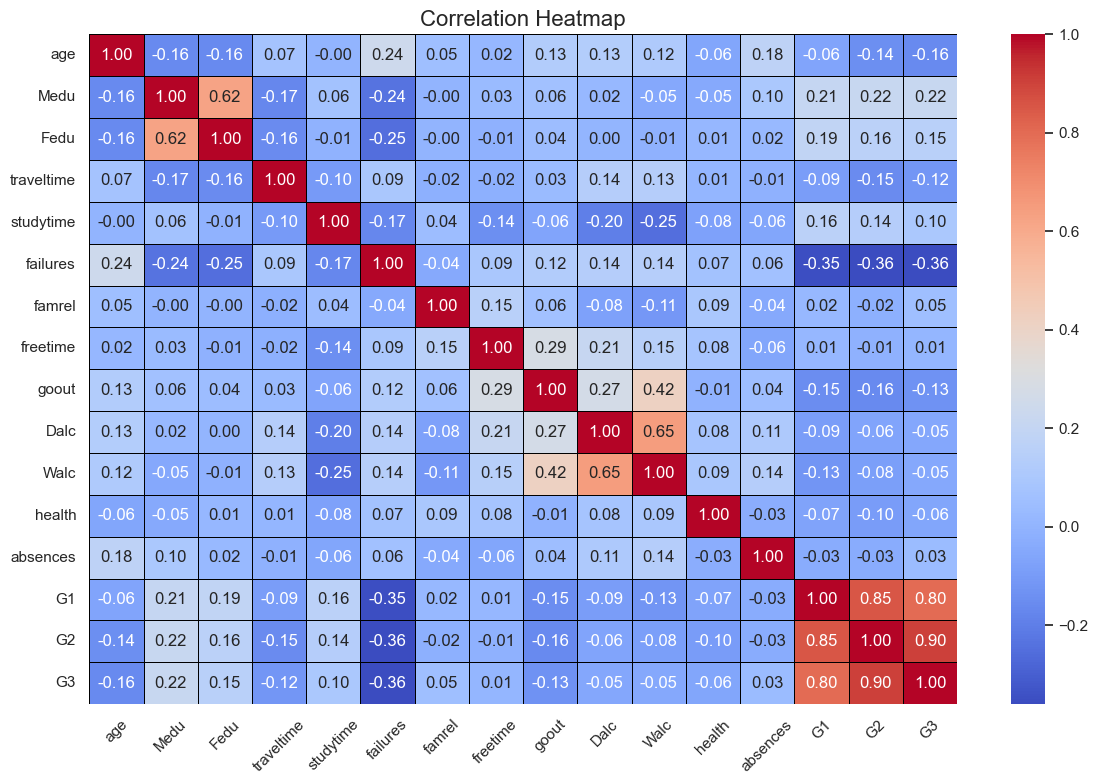

In [42]:
plt.figure(figsize=(12,8))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    linecolor='black'
)
plt.title("Correlation Heatmap", fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Result:** The graph shows that final grade (G3) is strongly related to previous grades (G1 and G2), indicating that past performance is a key factor in student success.

**Overall Conclusion:**

i)The analysis shows that student performance is mainly influenced by study time and previous academic scores.

ii) Students who study more tend to achieve higher final grades.

iii) Previous grades (G1 and G2) are strongly related to final performance (G3).

iv) Gender shows only slight variation in performance.

v) Most students fall in the average performance category.